<a href="https://colab.research.google.com/github/GandhiniP/demo/blob/main/faculty_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
   Faculty_ID  Experience_Years  Salary_Lakhs
0         F01               0.5          3.61
1         F02               1.0          3.72
2         F03               1.5          4.53
3         F04               2.0          4.39
4         F05               2.5          5.15
5         F06               3.0          5.81
6         F07               3.5          5.67
7         F08               4.0          6.53
8         F09               4.5          6.54
9         F10               5.0          7.15
10        F11               5.5          7.81
11        F12               6.0          7.62
12        F13               6.5          8.48
13        F14               7.0          9.14
14        F15               7.5          9.05
15        F16               8.0          9.76
16        F17               8.5          9.72
17        F18               9.0         10.73
18        F19               9.5         10.74
19        F20              10.0         11.30
20        F21            

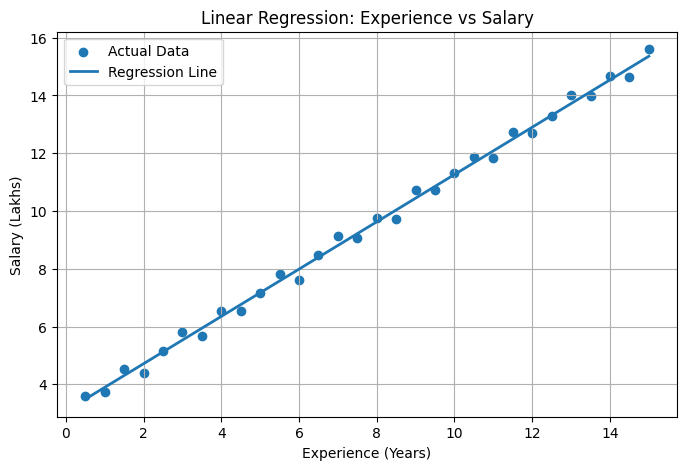


Predicted salary for 5 years of experience: 7.169769045156842 Lakhs


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load the dataset
df = pd.read_csv('/content/Faculty_Experience_Salary_Linear_Regression.csv')

# Step 3: Display the dataset
print("Dataset:")
print(df)

# Step 4: Display basic information
print("\nDataset Information:")
print(df.info())

# Step 5: Select Independent and Dependent Variables
X = df[['Experience_Years']]   # Independent variable
y = df['Salary_Lakhs']         # Dependent variable

# Step 6: Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Create Linear Regression model
model = LinearRegression()

# Step 8: Train the model
model.fit(X_train, y_train)

# Step 9: Predict salary for test data
y_pred = model.predict(X_test)

# Step 10: Display coefficients
print("\nIntercept:", model.intercept_)
print("Slope:", model.coef_[0])

# Step 11: Display predictions
results = pd.DataFrame({
    'Experience_Years': X_test['Experience_Years'],
    'Actual_Salary': y_test,
    'Predicted_Salary': y_pred
})

print("\nActual vs Predicted Salary:")
print(results.sort_values('Experience_Years'))

# Step 12: Calculate Mean Squared Error and R² Score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R² Score:", r2)

# Step 13: Plot the regression line
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label='Actual Data')

plt.plot(
    X,
    model.predict(X),
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Experience (Years)')
plt.ylabel('Salary (Lakhs)')
plt.title('Linear Regression: Experience vs Salary')
plt.legend()
plt.grid(True)

plt.show()

# Step 14: Predict salary for a new faculty member
new_experience = [[5]]

predicted_salary = model.predict(new_experience)

print("\nPredicted salary for 5 years of experience:",
      predicted_salary[0], "Lakhs")